<a href="https://colab.research.google.com/github/Tolureis/CMPE-403-Fundamentals-of-Image-Processing/blob/main/Image_Sampling_Quantization_Zooming_Shrinking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Sampling, Quantization, Zooming, and Shrinking

This notebook demonstrates fundamental operations in digital image processing using OpenCV in Python.
We cover the following topics:

* **Sampling** – converting a continuous image into a discrete grid of pixels.
* **Quantization** – mapping continuous intensity values to a finite set of levels.
* **Zooming (Upsampling)** – increasing image size using interpolation.
* **Shrinking (Downsampling)** – decreasing image size by decimation.

Understanding these operations is important when working with digital images. Sampling determines **where** pixel values are taken from an image, while quantization determines **how many intensity levels** each pixel can have. Zooming and shrinking are both forms of resampling where we either create new pixel locations or remove existing ones.

## Sampling
Image sampling is the process of converting a continuous image into a discrete form by selecting a finite number of points (pixels) from the image plane. It controls the spatial resolution: **how many pixels** are used to represent the image. A higher sampling rate means more pixels and finer detail, while a lower sampling rate means fewer pixels and potential loss of detail.

## Quantization
Image quantization is the process of mapping a large set of continuous or discrete intensity values to a smaller, finite set of levels. It controls the intensity or colour resolution: **how accurately** each pixel’s intensity can be represented. More quantization levels yield smoother tonal transitions, while fewer levels cause banding or visible steps in gradients.

## Shrinking (Downsampling)
Shrinking, or downsampling, reduces the image size. The lecture notes illustrate shrinking an 8‑bit image by half by selecting rows and columns at regular intervals (e.g., every second pixel). This process removes pixels and reduces resolution, which can lead to loss of detail and aliasing if not properly filtered beforehand.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper function for plotting multiple images
def show_images(images, titles, cmap=None):
    fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        if cmap:
            ax.imshow(img, cmap=cmap)
        else:
            # If image has 3 channels (colour), convert from BGR to RGB for display
            if len(img.shape) == 3 and img.shape[2] == 3:
                img_show = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            else:
                img_show = img
            ax.imshow(img_show, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.show()

### Create a synthetic test image
For demonstration, we generate a synthetic grayscale image with sinusoidal patterns. Generating an image in code removes any external dependencies and makes the notebook self‑contained.

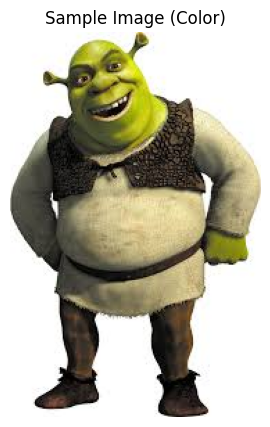

In [ ]:
# Load a sample image from a file
# Read the image in BGR format using OpenCV (ensure the file is in the same directory as this notebook)
img_color = cv2.imread('/content/shrek.jpg')

# Convert to grayscale for sampling and quantization demonstrations

# Display the color and grayscale versions
show_images([img_color], ['Sample Image (Color)'], cmap=None)


### Sampling demonstration
We downsample the image by taking every 2nd and every 4th pixel in both dimensions. Downsampling reduces the spatial resolution by discarding pixels.

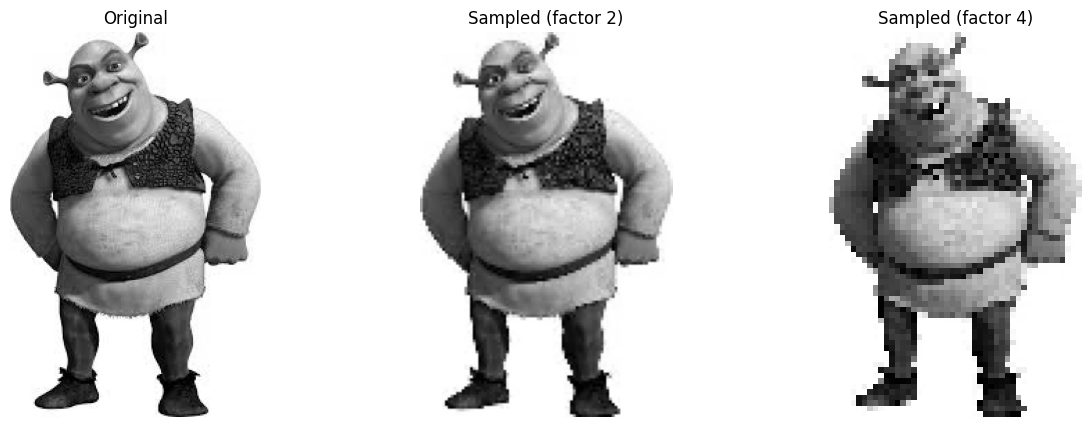

In [ ]:
# Downsample by a factor of 2 (take every second pixel)
sampled_2 = synthetic[::2, ::2]

# Downsample by a factor of 4
sampled_4 = synthetic[::4, ::4]

# Show original and sampled images
show_images([synthetic, sampled_2, sampled_4],
            ['Original', 'Sampled (factor 2)', 'Sampled (factor 4)'],
            cmap='gray')

### Quantization demonstration
Quantization reduces the number of intensity levels. Here we simulate 8‑bit (256 levels), 4‑bit (16 levels), and 2‑bit (4 levels) quantization by rounding pixel values to the nearest allowed level.

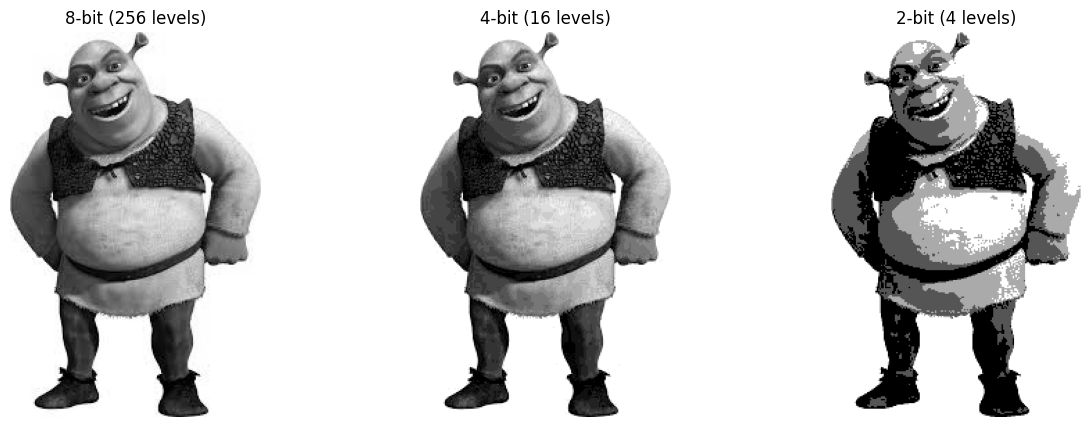

In [ ]:
def quantize(image, bits):
    """Reduce the intensity resolution of an image.
    bits: number of bits per pixel (e.g., 4 bits → 16 levels).
    """
    levels = 2 ** bits
    step = 256 // levels
    quantized = (image // step) * step + step // 2
    return quantized.astype(np.uint8)

img_8bit = quantize(synthetic, 8)  # 256 levels
img_4bit = quantize(synthetic, 4)  # 16 levels
img_2bit = quantize(synthetic, 2)  # 4 levels

show_images([img_8bit, img_4bit, img_2bit],
            ['8-bit (256 levels)', '4-bit (16 levels)', '2-bit (4 levels)'],
            cmap='gray')

### Shrinking demonstration
Shrinking (downsampling) reduces the image size. We shrink the image by half using OpenCV’s `INTER_AREA` interpolation, which is appropriate for reducing size because it averages pixel values to avoid aliasing. This corresponds to selecting rows and columns at regular intervals.

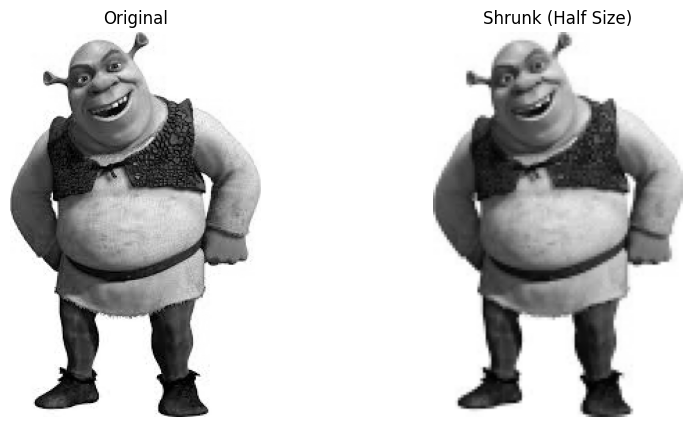

In [ ]:
# Shrink the image by a factor of 0.5 using area interpolation
shrink = cv2.resize(synthetic, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

show_images([synthetic, shrink], ['Original', 'Shrunk (Half Size)'], cmap='gray')